# African Flags Color Analysis - Visualizations

**Project:** Chromatic Connections - Analyzing color patterns in African flags  
**Notebook:** 04 Visualizations  
**Goal:** Create publication-quality visualizations of clustering results

**Input:** Clustered dataset from Notebook 03  
**Output:** High-resolution images for portfolio and presentation

---

## Section 1: Setup and Data Loading

Load clustered data and configure visualization settings.

In [10]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Configure paths
DATA_DIR = Path("../data")
FLAGS_DIR = DATA_DIR / "flags_images"
RAW_DIR = DATA_DIR / "raw"
VIZ_DIR = DATA_DIR / "visualizations"

# Create visualizations directory
VIZ_DIR.mkdir(exist_ok=True)

# Load clustered dataset
df = pd.read_csv(RAW_DIR / "african_flags_clustered.csv")

print("Setup complete")
print(f"Loaded {len(df)} countries with cluster assignments")
print(f"Visualizations will be saved to: {VIZ_DIR}")

# Set high-quality plotting parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Setup complete
Loaded 54 countries with cluster assignments
Visualizations will be saved to: ..\data\visualizations

Cluster distribution:
Cluster
1     3
2     2
3     4
4    26
5     9
6     9
7     1
Name: count, dtype: int64


---

## Section 2: Cluster Flag Grid - Hero Visualization

Display all 54 flags organized by cluster with descriptive titles.

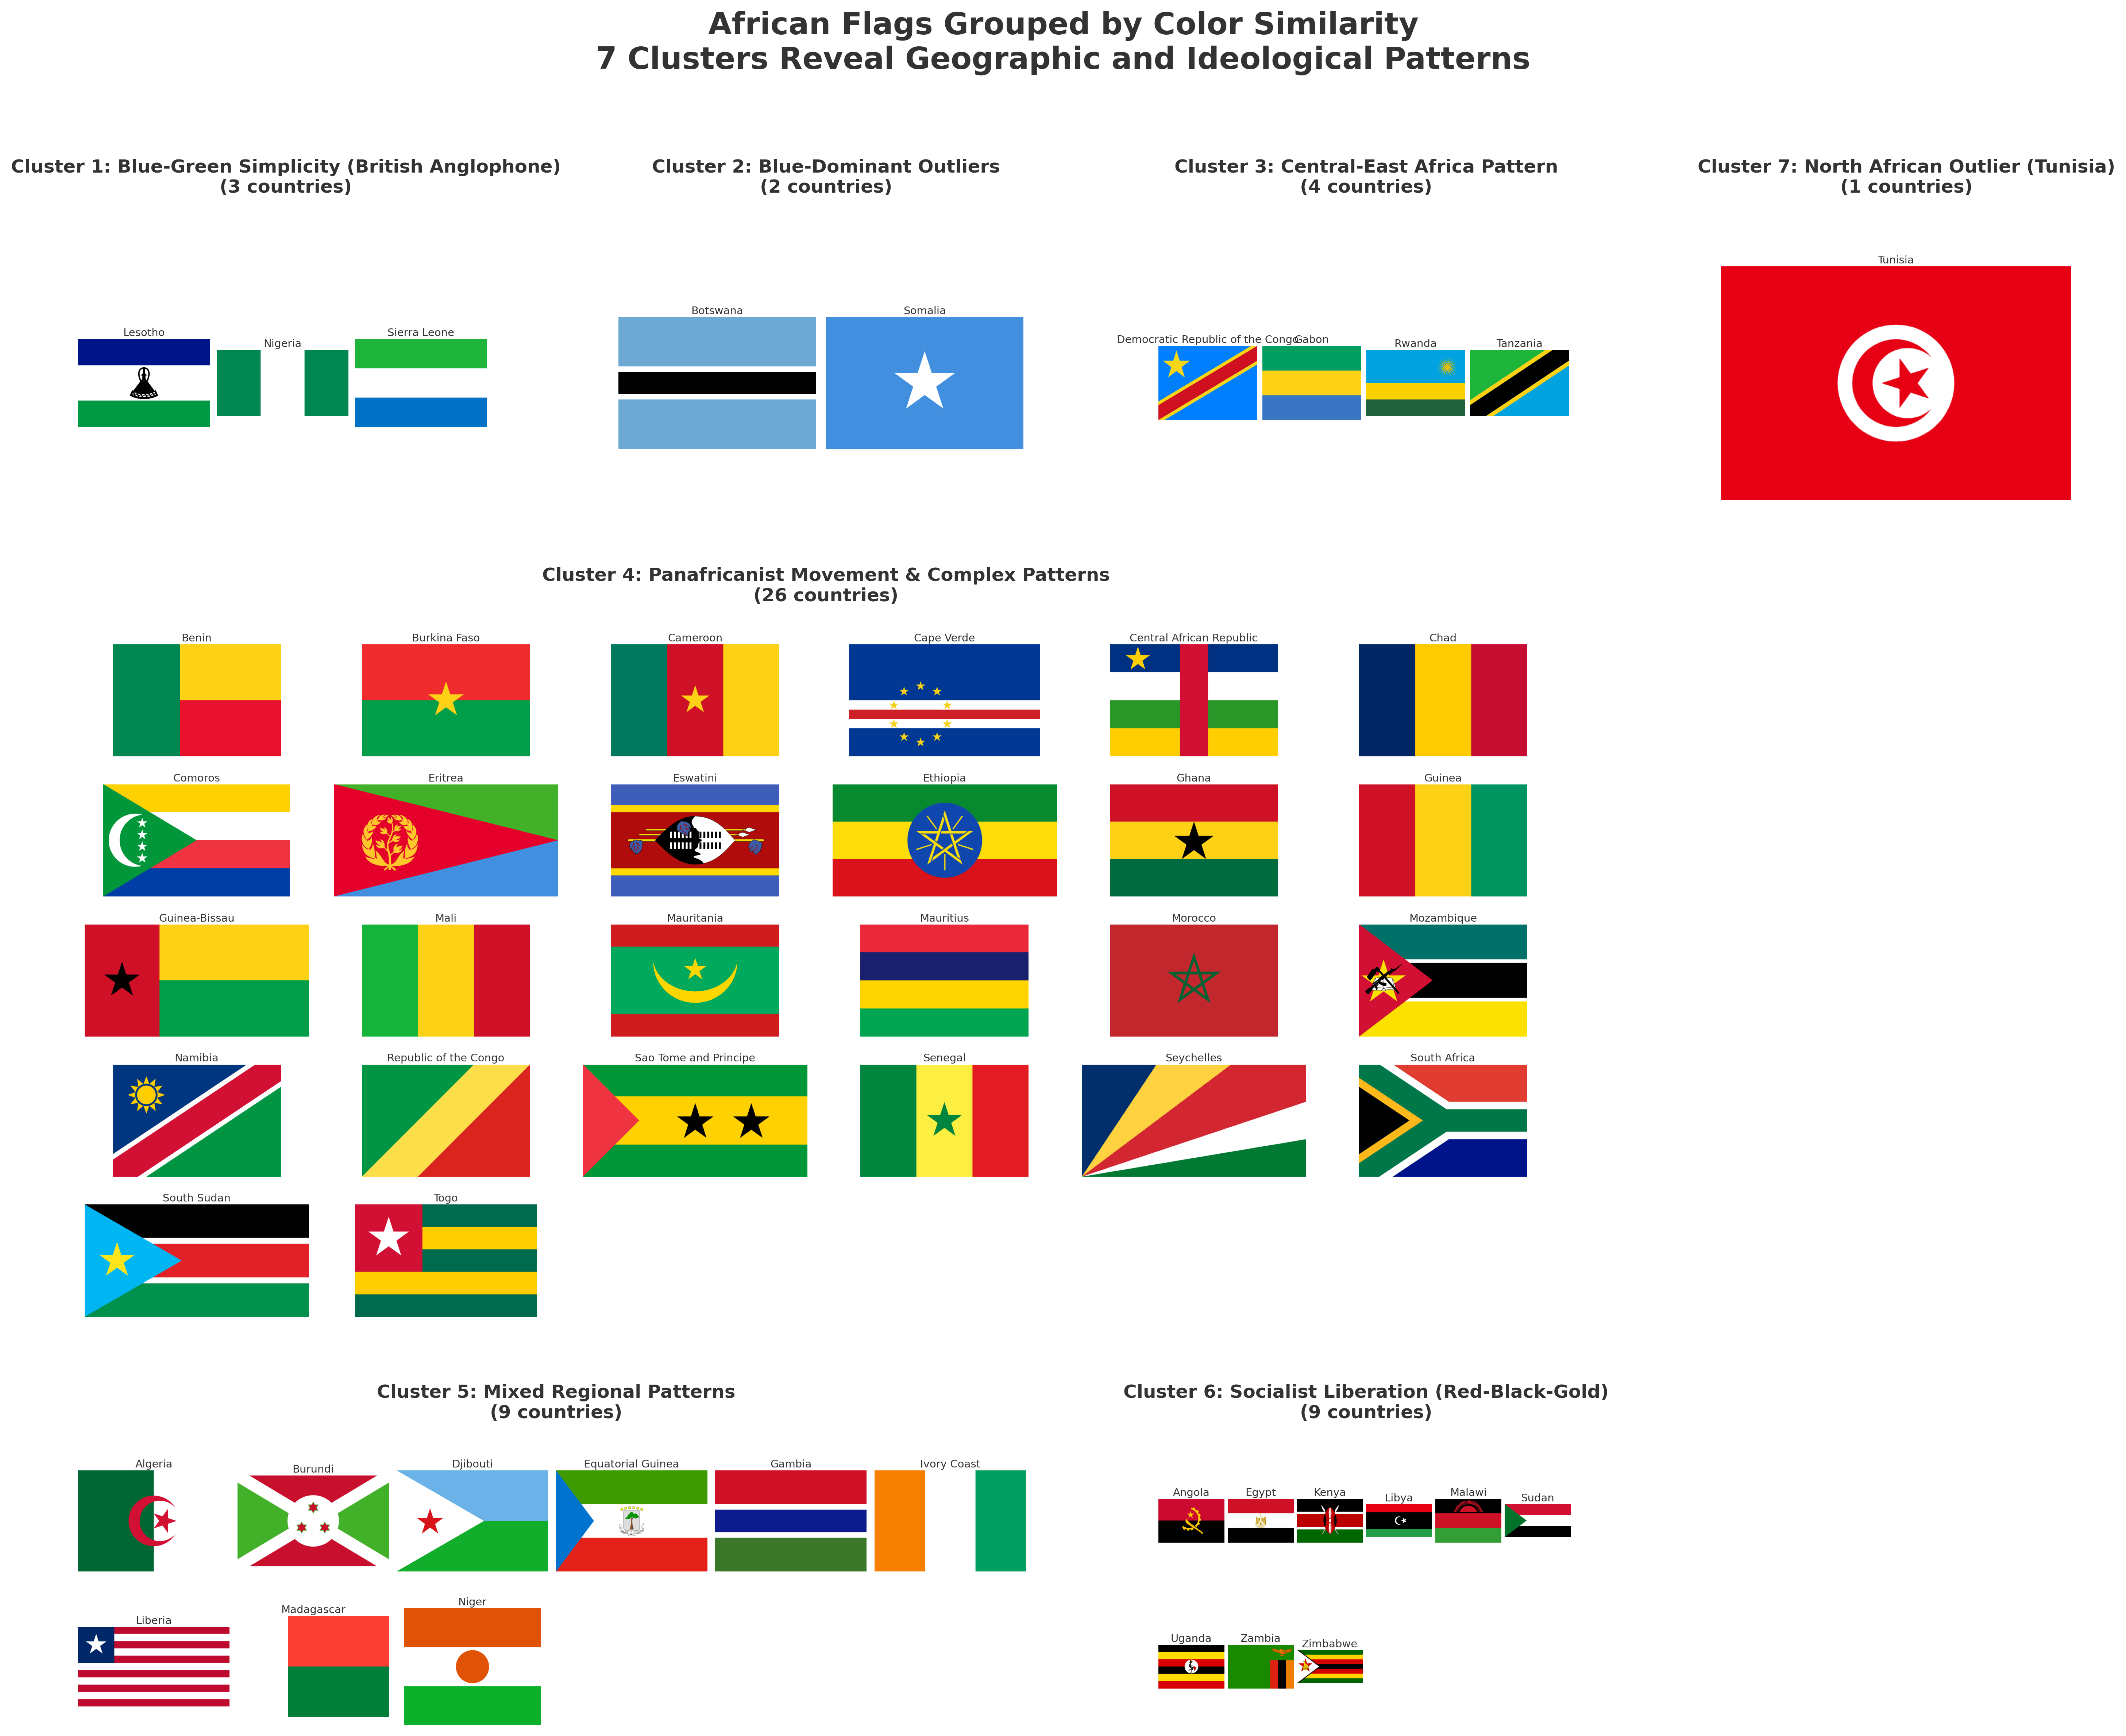

Hero image created and saved
File: ..\data\visualizations\01_cluster_flag_grid.png


In [11]:
# Define cluster names based on our analysis
cluster_names = {
    1: "Blue-Green Simplicity (British Anglophone)",
    2: "Blue-Dominant Outliers",
    3: "Central-East Africa Pattern",
    4: "Panafricanist Movement & Complex Patterns",
    5: "Mixed Regional Patterns",
    6: "Socialist Liberation (Red-Black-Gold)",
    7: "North African Outlier (Tunisia)"
}

# Create comprehensive grid
fig = plt.figure(figsize=(24, 18))
fig.suptitle('African Flags Grouped by Color Similarity\n7 Clusters Reveal Geographic and Ideological Patterns', 
             fontsize=20, fontweight='bold', y=0.98)

# Calculate grid layout: 7 clusters, arrange them efficiently
cluster_positions = {
    1: (0, 0, 1, 1),  # (row_start, col_start, row_span, col_span)
    2: (0, 1, 1, 1),
    3: (0, 2, 1, 1),
    4: (1, 0, 2, 3),  # Large cluster gets more space
    5: (3, 0, 1, 2),
    6: (3, 2, 1, 1),
    7: (0, 3, 1, 1)
}

gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.3)

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_df = df[df['Cluster'] == cluster_id].sort_values('Country')
    n_flags = len(cluster_df)
    
    # Get position for this cluster
    row_start, col_start, row_span, col_span = cluster_positions[cluster_id]
    
    # Create subplot for this cluster
    ax = fig.add_subplot(gs[row_start:row_start+row_span, col_start:col_start+col_span])
    ax.set_title(f"Cluster {cluster_id}: {cluster_names[cluster_id]}\n({n_flags} countries)", 
                 fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')
    
    # Determine grid size for flags within this cluster
    cols = min(6, n_flags)
    rows = (n_flags + cols - 1) // cols
    
    # Plot each flag
    for idx, (_, row) in enumerate(cluster_df.iterrows()):
        country = row['Country']
        flag_path = FLAGS_DIR / f"{country.replace(' ', '_')}.png"
        
        if flag_path.exists():
            img = Image.open(flag_path)
            
            # Calculate position within cluster grid
            flag_row = idx // cols
            flag_col = idx % cols
            
            # Create small axes for this flag
            left = flag_col / cols
            bottom = 1 - (flag_row + 1) / rows
            width = 0.95 / cols
            height = 0.8 / rows
            
            flag_ax = ax.inset_axes([left, bottom, width, height])
            flag_ax.imshow(img)
            flag_ax.set_title(country, fontsize=7, pad=2)
            flag_ax.axis('off')

plt.tight_layout()
plt.savefig(VIZ_DIR / "01_cluster_flag_grid.png", bbox_inches='tight', facecolor='white')
plt.show()

print("Hero image created and saved")
print(f"File: {VIZ_DIR / '01_cluster_flag_grid.png'}")

---

## Section 3: Color Palette Comparison by Cluster

Visualize the dominant color schemes for each cluster.

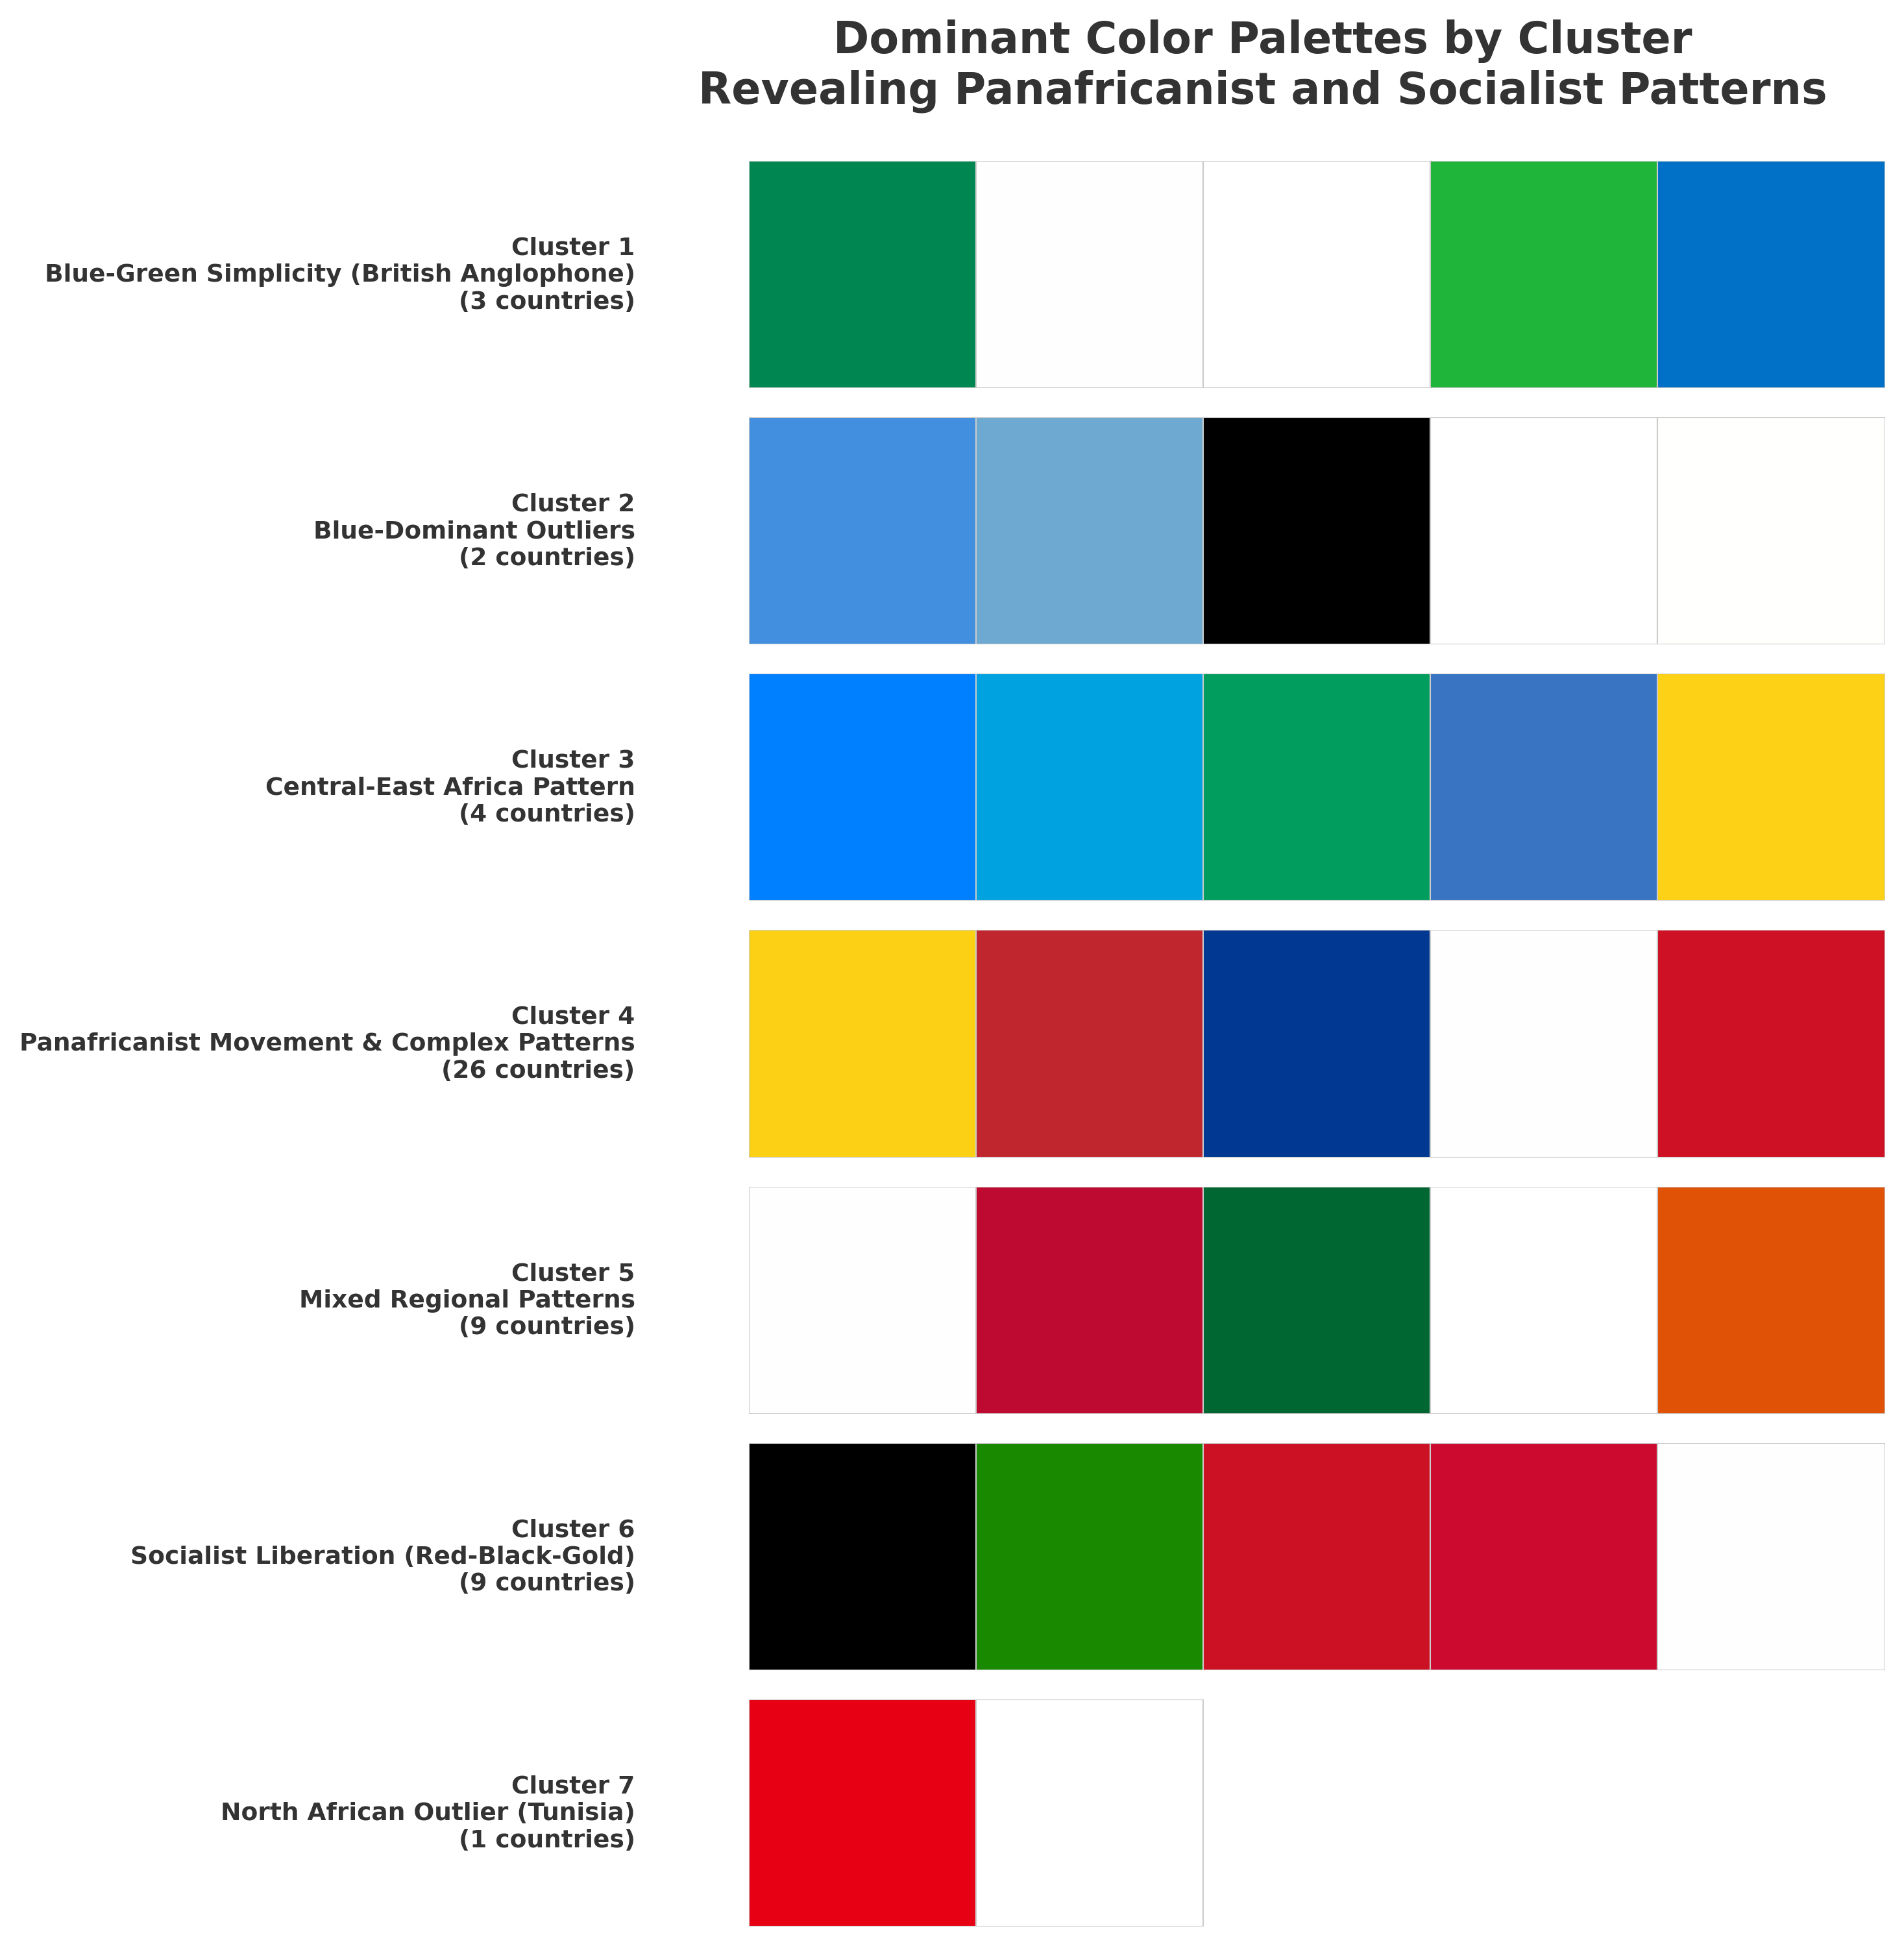

Color palette visualization with fine gray borders created
File: ..\data\visualizations\02_cluster_color_palettes.png


In [12]:
# Extract representative colors for each cluster
cluster_palettes = {}
import ast

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_df = df[df['Cluster'] == cluster_id]
    
    # Collect all colors from all flags in this cluster
    all_colors = []
    for _, row in cluster_df.iterrows():
        colors = ast.literal_eval(row['All_Colors_Hex']) if isinstance(row['All_Colors_Hex'], str) else row['All_Colors_Hex']
        proportions = ast.literal_eval(row['All_Proportions']) if isinstance(row['All_Proportions'], str) else row['All_Proportions']
        # Weight colors by their proportions
        for color, prop in zip(colors, proportions):
            all_colors.extend([color] * int(prop * 100))  # Repeat by proportion
    
    # Get most common colors in this cluster
    from collections import Counter
    color_counts = Counter(all_colors)
    top_colors = [color for color, count in color_counts.most_common(5)]
    
    cluster_palettes[cluster_id] = top_colors

# Create palette comparison visualization with fine gray borders
fig, axes = plt.subplots(7, 1, figsize=(14, 10))
fig.suptitle('Dominant Color Palettes by Cluster\nRevealing Panafricanist and Socialist Patterns', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, cluster_id in enumerate(sorted(df['Cluster'].unique())):
    ax = axes[idx]
    colors = cluster_palettes[cluster_id]
    n_countries = len(df[df['Cluster'] == cluster_id])
    
    # Create color bar with very fine gray borders
    for i, color in enumerate(colors):
        ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, 
                                       facecolor=color, 
                                       edgecolor='#cccccc',  # Light gray border
                                       linewidth=0.5))  # Very thin border
    
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Add cluster label
    cluster_name = cluster_names[cluster_id]
    ax.text(-0.5, 0.5, f"Cluster {cluster_id}\n{cluster_name}\n({n_countries} countries)", 
            va='center', ha='right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_cluster_color_palettes.png", bbox_inches='tight', facecolor='white')
plt.show()

print("Color palette visualization with fine gray borders created")
print(f"File: {VIZ_DIR / '02_cluster_color_palettes.png'}")

---

## Section 4: Geographic Cluster Map

Visualize cluster distribution across the African continent to show regional patterns.

Loaded 51 African countries from Natural Earth
Matched 47 countries with cluster data


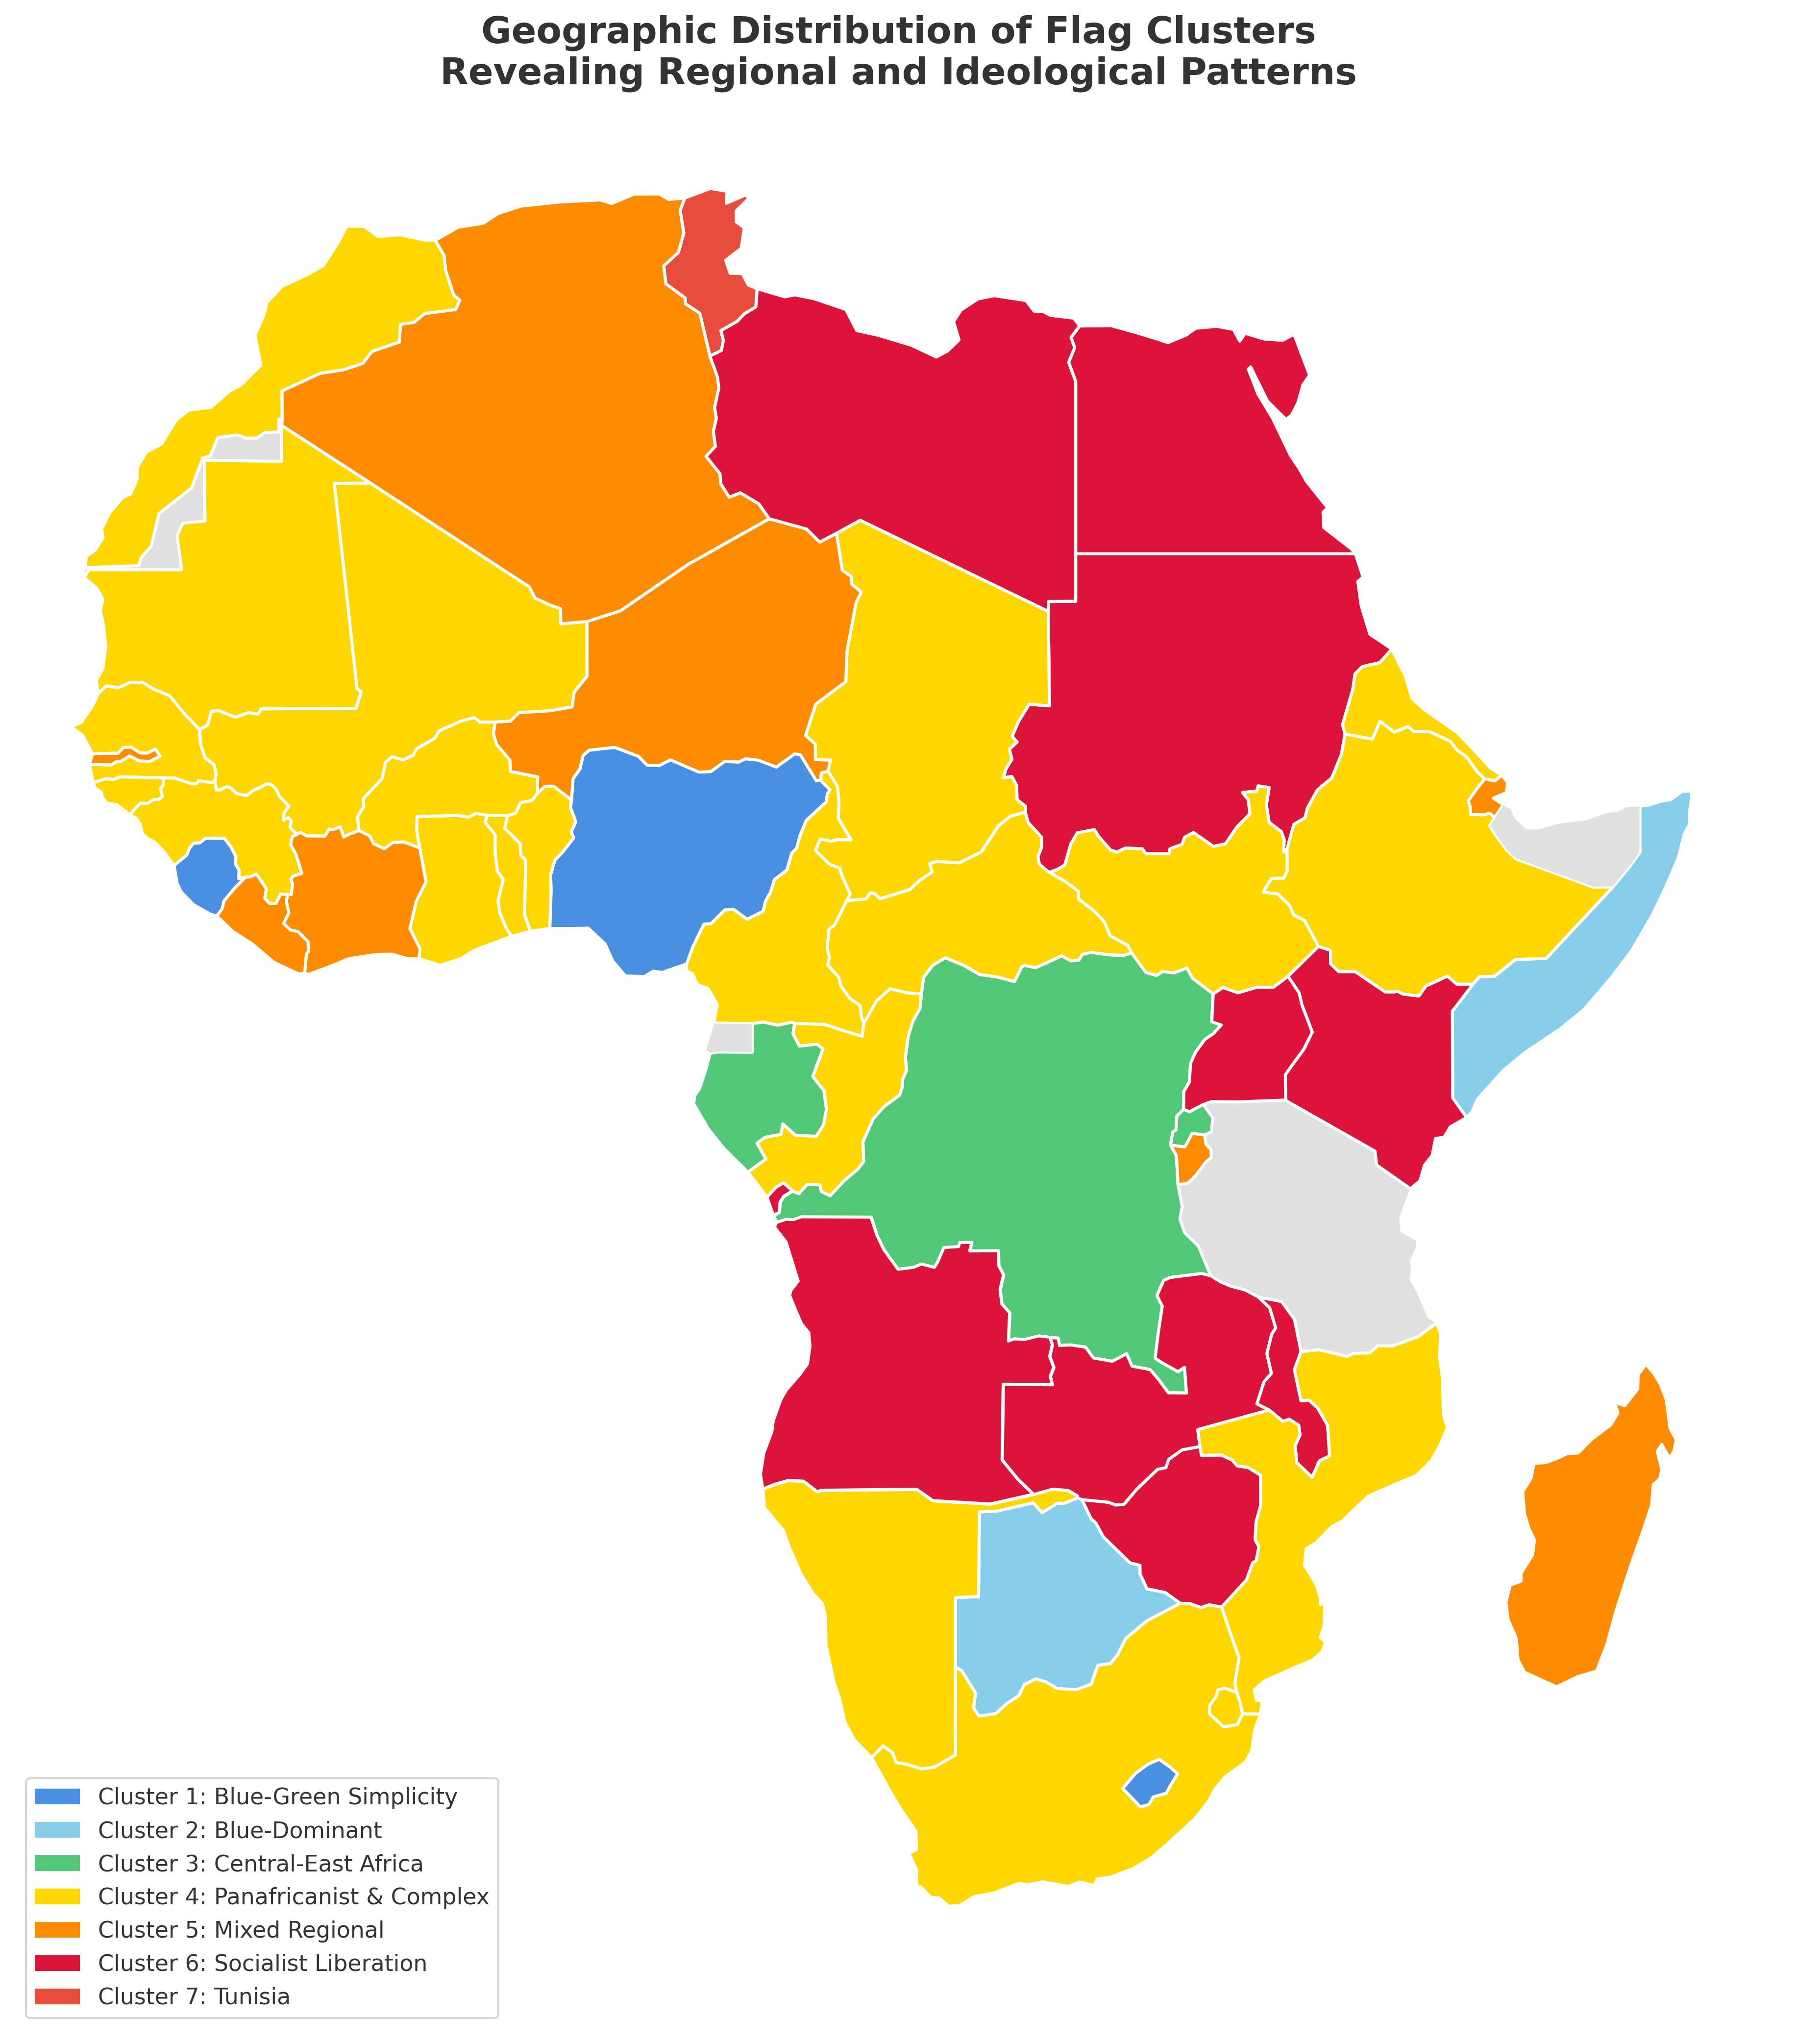


Geographic cluster map created and saved
File: ..\data\visualizations\03_geographic_cluster_map.png


In [13]:
import geopandas as gpd
import matplotlib.patches as mpatches

# Download Natural Earth data directly
print("Downloading Natural Earth data...")
world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

# Filter to Africa
africa = world[world.CONTINENT == 'Africa'].copy()

print(f"Loaded {len(africa)} African countries from Natural Earth")

# Map country names to match our dataset
name_mapping = {
    'Democratic Republic of the Congo': 'Dem. Rep. Congo',
    'Republic of the Congo': 'Congo',
    'Central African Republic': 'Central African Rep.',
    'South Sudan': 'S. Sudan',
    'Ivory Coast': "Côte d'Ivoire",
    'Eswatini': 'eSwatini',
    'Tanzania': 'United Rep. of Tanzania'
}

df['GeoName'] = df['Country'].replace(name_mapping)

# Merge cluster data
africa_clusters = africa.merge(
    df[['GeoName', 'Cluster']], 
    left_on='NAME', 
    right_on='GeoName', 
    how='left'
)

print(f"Matched {africa_clusters['Cluster'].notna().sum()} countries with cluster data")

# Create the map
fig, ax = plt.subplots(figsize=(16, 14))

# Define cluster colors
cluster_colors = {
    1: '#4A90E2',  # Blue
    2: '#87CEEB',  # Light blue
    3: '#50C878',  # Emerald
    4: '#FFD700',  # Gold (Panafricanist)
    5: '#FF8C00',  # Orange
    6: '#DC143C',  # Crimson (Socialist)
    7: '#E74C3C'   # Red (Tunisia)
}

# Plot countries
for idx, row in africa_clusters.iterrows():
    if pd.notna(row['Cluster']):
        color = cluster_colors[int(row['Cluster'])]
        africa_clusters[africa_clusters.index == idx].plot(
            ax=ax, 
            color=color, 
            edgecolor='white', 
            linewidth=1.5
        )
    else:
        africa_clusters[africa_clusters.index == idx].plot(
            ax=ax, 
            color='#E0E0E0', 
            edgecolor='white', 
            linewidth=0.5
        )

ax.set_xlim(-20, 55)
ax.set_ylim(-40, 40)
ax.axis('off')

ax.set_title('Geographic Distribution of Flag Clusters\nRevealing Regional and Ideological Patterns', 
             fontsize=18, fontweight='bold', pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=cluster_colors[1], label='Cluster 1: Blue-Green Simplicity'),
    mpatches.Patch(facecolor=cluster_colors[2], label='Cluster 2: Blue-Dominant'),
    mpatches.Patch(facecolor=cluster_colors[3], label='Cluster 3: Central-East Africa'),
    mpatches.Patch(facecolor=cluster_colors[4], label='Cluster 4: Panafricanist & Complex'),
    mpatches.Patch(facecolor=cluster_colors[5], label='Cluster 5: Mixed Regional'),
    mpatches.Patch(facecolor=cluster_colors[6], label='Cluster 6: Socialist Liberation'),
    mpatches.Patch(facecolor=cluster_colors[7], label='Cluster 7: Tunisia')
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=11, frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_geographic_cluster_map.png", bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

print("\nGeographic cluster map created and saved")
print(f"File: {VIZ_DIR / '03_geographic_cluster_map.png'}")

---

## Section 5: Timeline of Flag Adoptions

Visualize when flags were adopted to show the 1960s independence wave and cluster patterns over time.

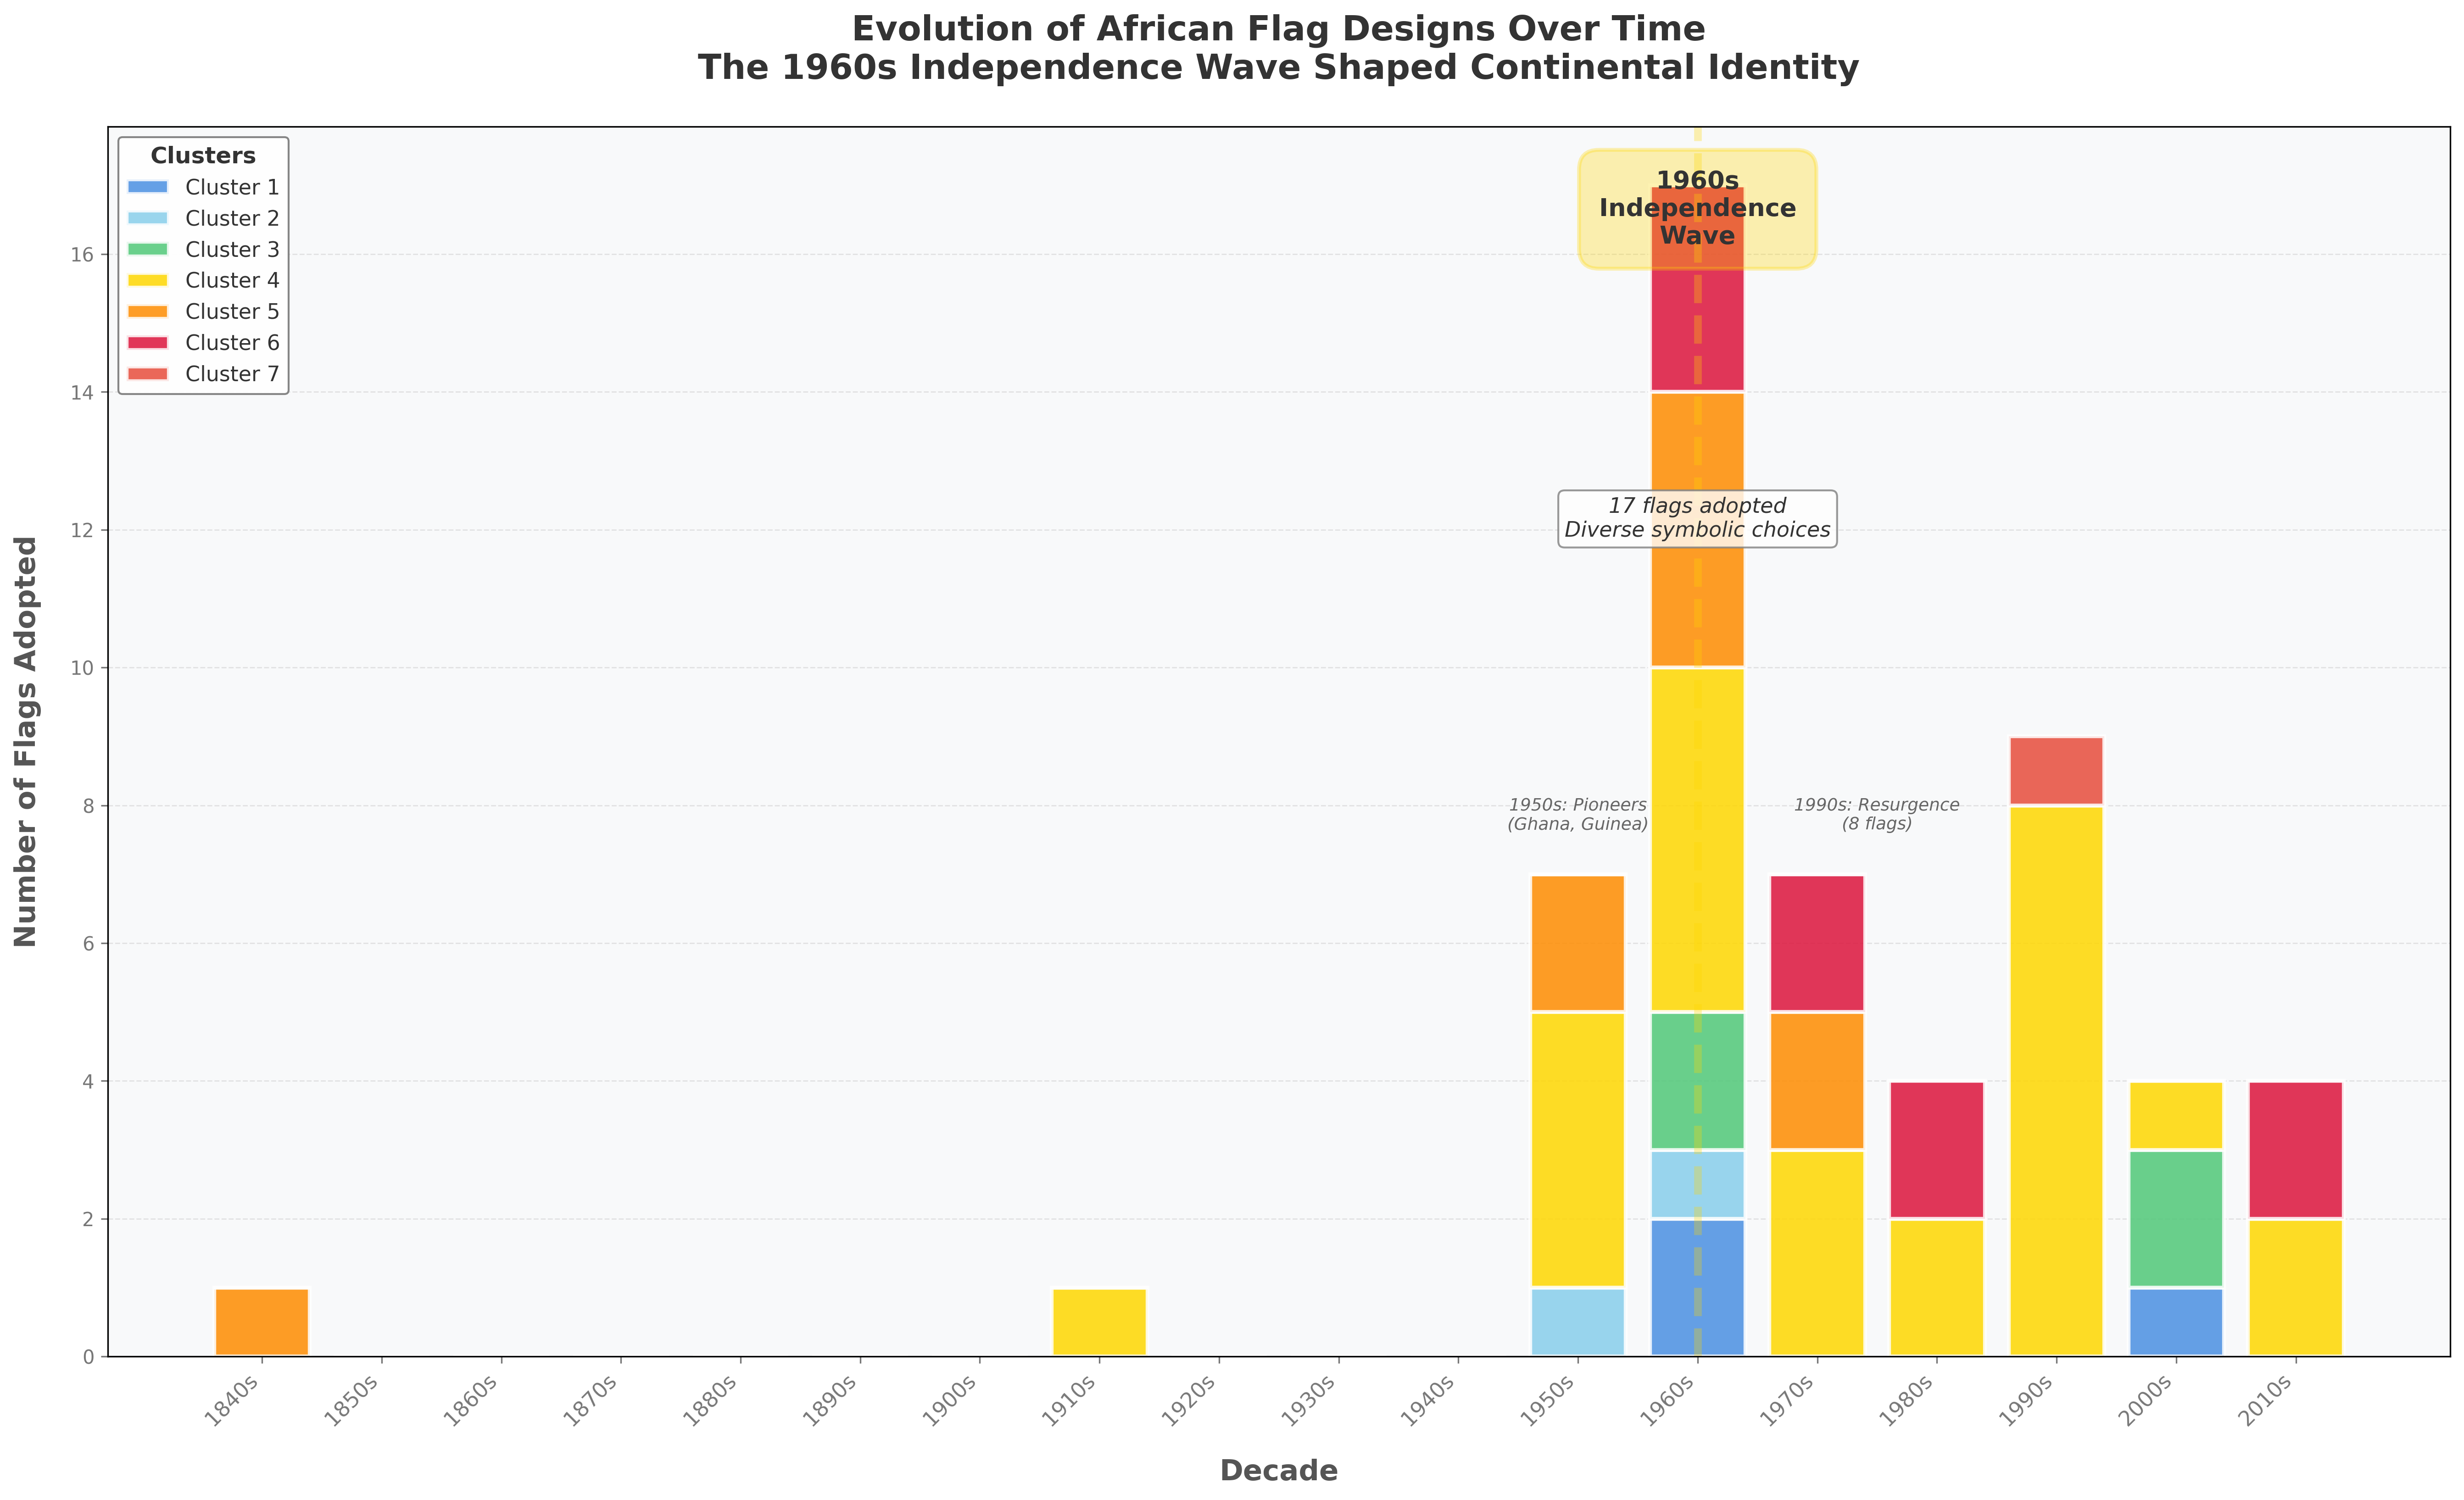

Timeline visualization created and saved
File: ..\data\visualizations\04_timeline_flag_adoptions.png

1960s Statistics:
  Total flags adopted: 17
  Panafricanist (Cluster 4): 5
  Percentage Panafricanist: 29.4%


In [14]:
# Create a timeline visualization
fig, ax = plt.subplots(figsize=(18, 11))

# Set elegant background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Create decade bins manually
decade_bins = list(range(1840, 2030, 10))
decade_labels = [f"{y}s" for y in range(1840, 2020, 10)]

# Count flags by decade and cluster
decade_cluster_counts = {}
for decade_start in decade_bins[:-1]:
    decade_end = decade_start + 9
    decade_label = f"{decade_start}s"
    decade_cluster_counts[decade_label] = {}
    
    for cluster_id in sorted(df['Cluster'].unique()):
        count = len(df[(df['Flag_Adoption_Year'] >= decade_start) & 
                       (df['Flag_Adoption_Year'] <= decade_end) & 
                       (df['Cluster'] == cluster_id)])
        decade_cluster_counts[decade_label][cluster_id] = count

# Convert to plottable format
x_pos = np.arange(len(decade_labels))
bottom = np.zeros(len(decade_labels))

# Plot bars for each cluster
for cluster_id in sorted(df['Cluster'].unique()):
    values = [decade_cluster_counts[decade][cluster_id] for decade in decade_labels]
    ax.bar(x_pos, values, bottom=bottom, 
           color=cluster_colors[cluster_id],
           edgecolor='white', linewidth=2,
           label=f'Cluster {cluster_id}', alpha=0.85, width=0.8)
    bottom += np.array(values)

# Highlight 1960s (index 12 for 1960s in the list)
highlight_idx = decade_labels.index('1960s')
ax.axvline(x=highlight_idx, color='gold', linewidth=4, alpha=0.3, linestyle='--')

# Add annotation for 1960s
count_1960s = df[df['Flag_Adoption_Decade'] == 1960].shape[0]
count_cluster4_1960s = df[(df['Flag_Adoption_Decade'] == 1960) & (df['Cluster'] == 4)].shape[0]

ax.text(highlight_idx, max(bottom) * 0.95, '1960s\nIndependence\nWave', 
        ha='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='gold', alpha=0.3, edgecolor='gold', linewidth=2))

ax.text(highlight_idx, max(bottom) * 0.70, f'{count_1960s} flags adopted\nDiverse symbolic choices', 
        ha='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=1))

# Add annotation about three waves of Panafricanism
ax.text(11, max(bottom) * 0.45, '1950s: Pioneers\n(Ghana, Guinea)', 
        ha='center', fontsize=9, style='italic', color='#666666')

ax.text(13.5, max(bottom) * 0.45, '1990s: Resurgence\n(8 flags)', 
        ha='center', fontsize=9, style='italic', color='#666666')

# Styling
ax.set_xlabel('Decade', fontsize=15, fontweight='bold', labelpad=15)
ax.set_ylabel('Number of Flags Adopted', fontsize=15, fontweight='bold', labelpad=15)
ax.set_title('Evolution of African Flag Designs Over Time\nThe 1960s Independence Wave Shaped Continental Identity', 
             fontsize=18, fontweight='bold', pad=25)

ax.set_xticks(x_pos)
ax.set_xticklabels(decade_labels, rotation=45, ha='right', fontsize=11)
ax.set_ylim(0, max(bottom) * 1.05)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# Legend
legend = ax.legend(loc='upper left', fontsize=11, frameon=True, 
                   facecolor='white', edgecolor='gray', framealpha=0.95,
                   title='Clusters', title_fontsize=12)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / "04_timeline_flag_adoptions.png", bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

print("Timeline visualization created and saved")
print(f"File: {VIZ_DIR / '04_timeline_flag_adoptions.png'}")
print(f"\n1960s Statistics:")
print(f"  Total flags adopted: {count_1960s}")
print(f"  Panafricanist (Cluster 4): {count_cluster4_1960s}")
print(f"  Percentage Panafricanist: {(count_cluster4_1960s/count_1960s)*100:.1f}%")

---

## Section 6: Research Question Summary Infographic

Create a comprehensive one-page visual summary of findings for presentations and portfolio.

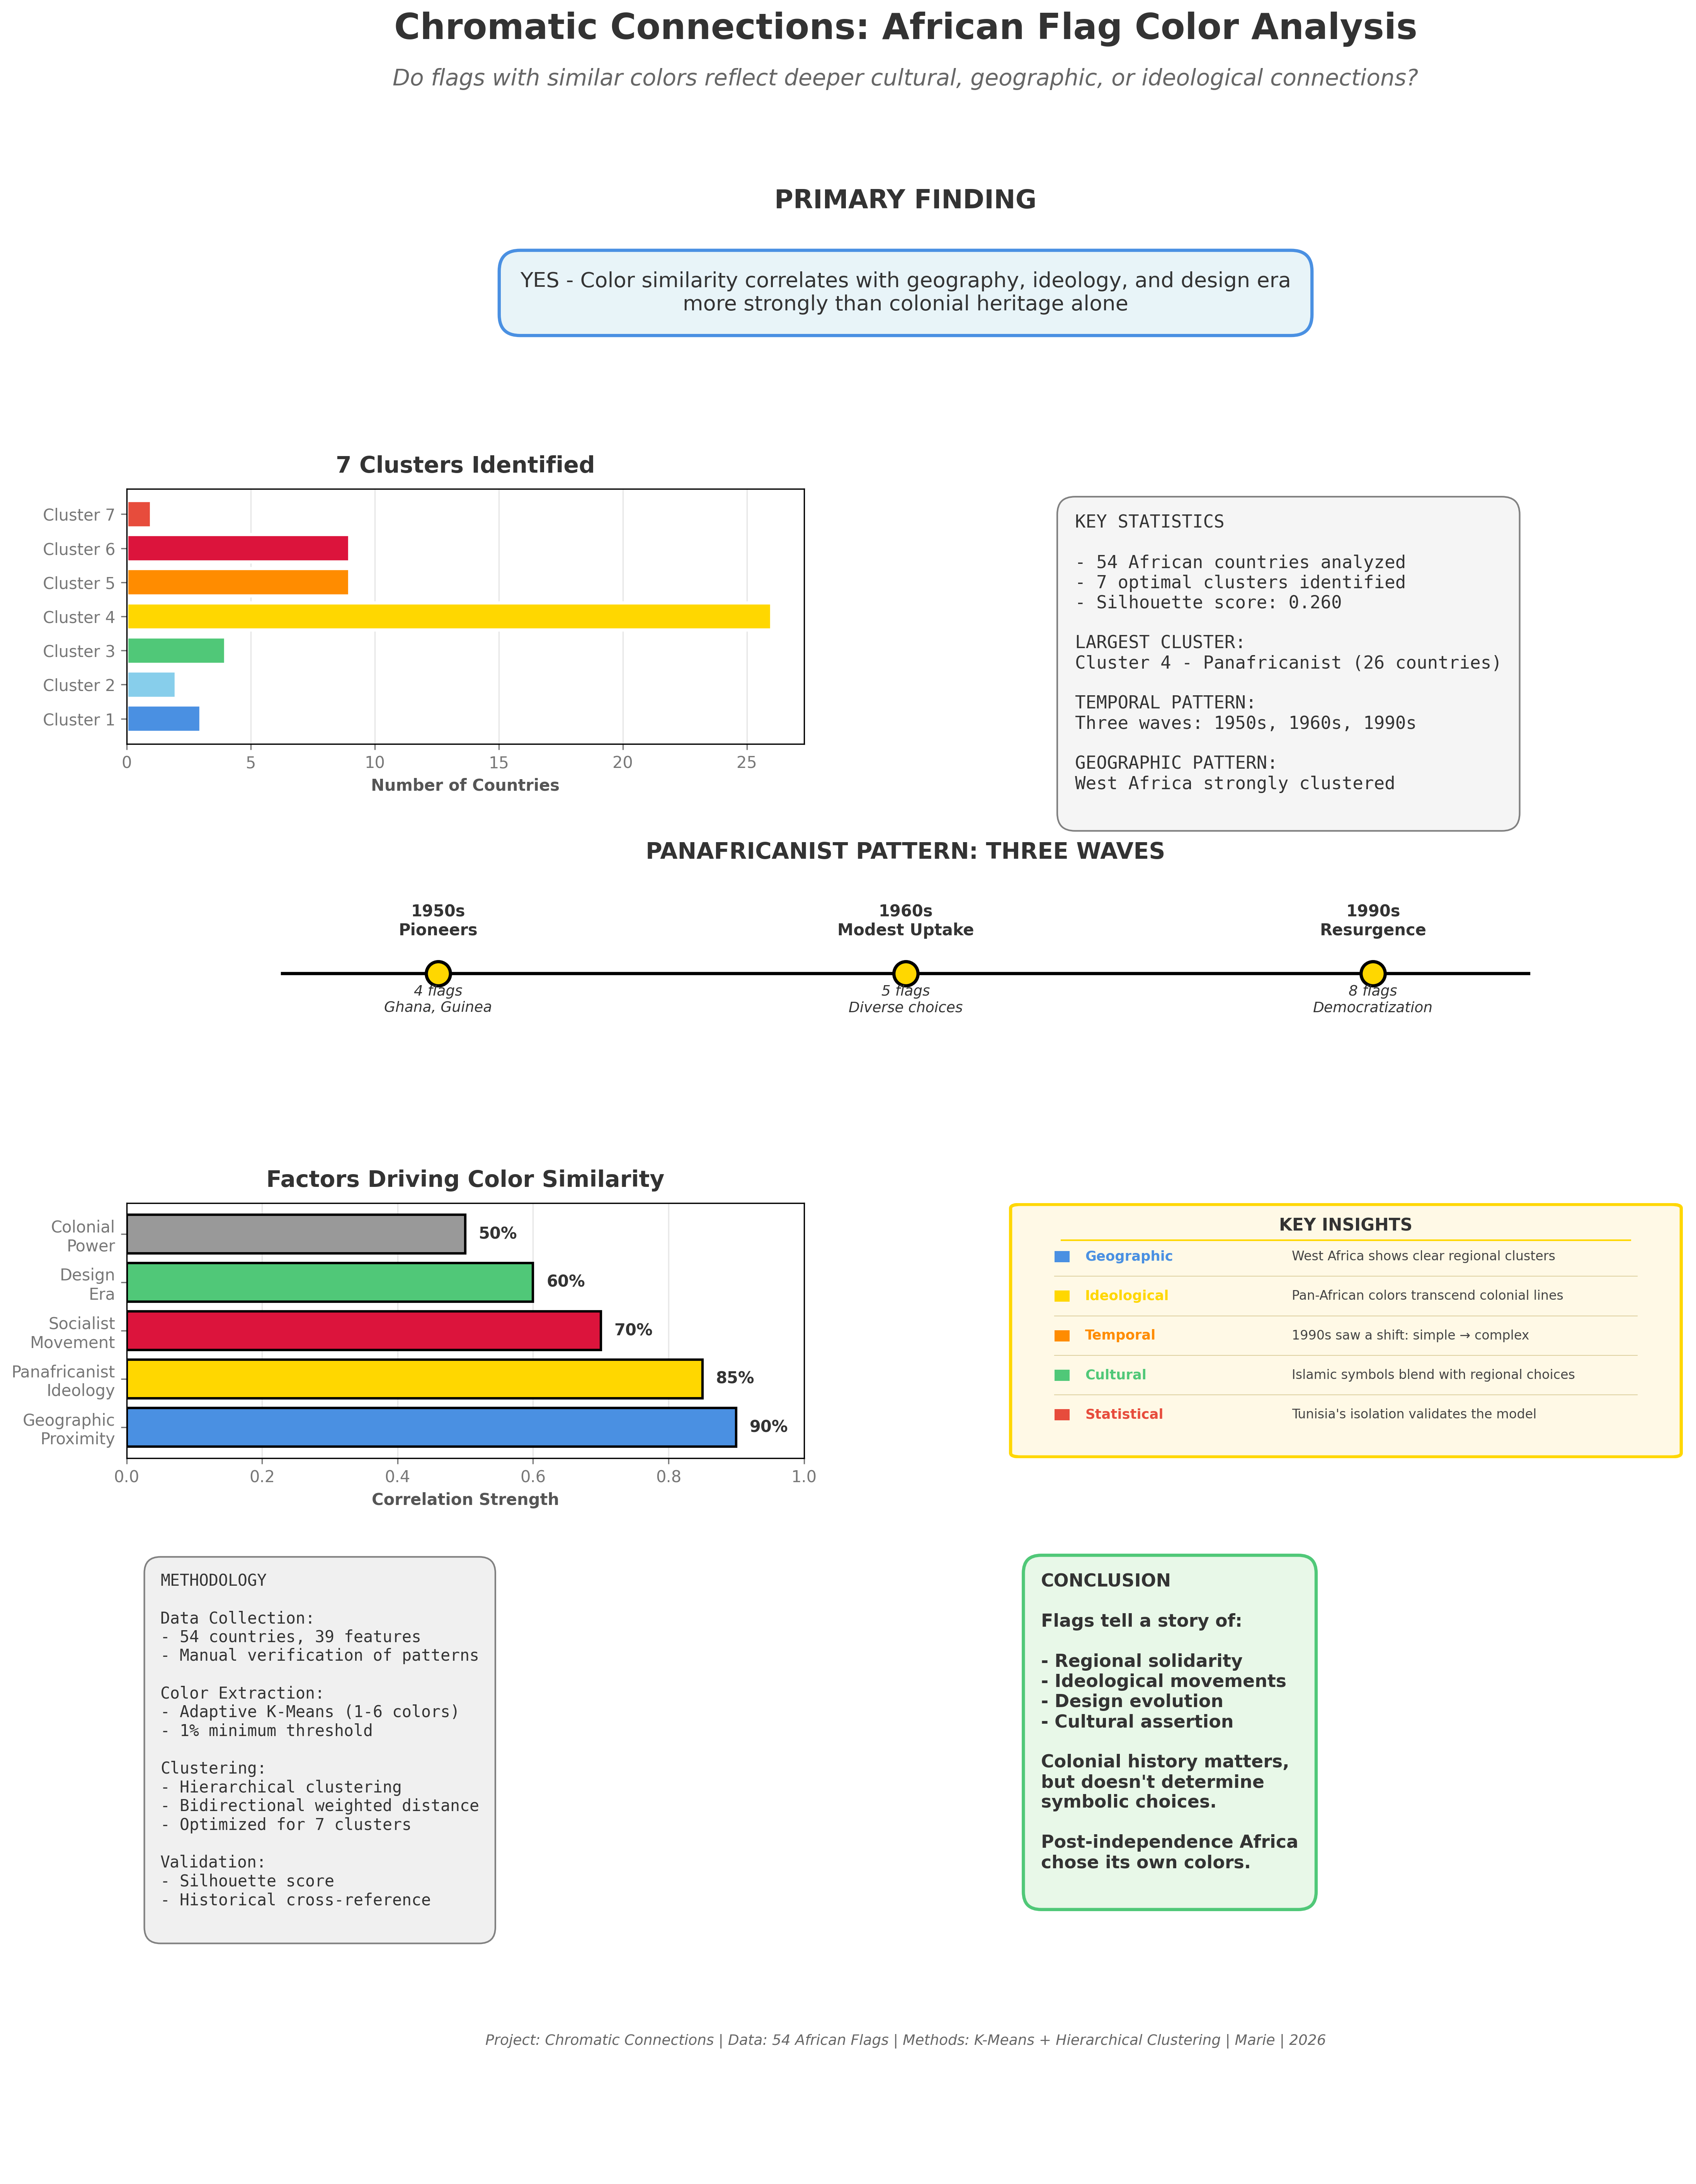

Research summary infographic created and saved
File: ..\data\visualizations\05_research_summary_infographic.png

This one-page summary is perfect for:
  - Portfolio presentations
  - Academic posters
  - Quick project overview
  - Master's application materials


In [20]:
# Create research question summary infographic
fig = plt.figure(figsize=(16, 20))
fig.patch.set_facecolor('white')

# Title
fig.text(0.5, 0.97, 'Chromatic Connections: African Flag Color Analysis', 
         ha='center', fontsize=22, fontweight='bold')
fig.text(0.5, 0.95, 'Do flags with similar colors reflect deeper cultural, geographic, or ideological connections?', 
         ha='center', fontsize=14, style='italic', color='#666666')

# Create grid layout
gs = fig.add_gridspec(6, 2, hspace=0.4, wspace=0.3, 
                      left=0.08, right=0.92, top=0.93, bottom=0.05)

# Section 1: Research Question (top banner)
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')
ax1.text(0.5, 0.7, 'PRIMARY FINDING', ha='center', fontsize=16, fontweight='bold', 
         transform=ax1.transAxes)
ax1.text(0.5, 0.3, 'YES - Color similarity correlates with geography, ideology, and design era\nmore strongly than colonial heritage alone', 
         ha='center', fontsize=13, transform=ax1.transAxes, 
         bbox=dict(boxstyle='round,pad=1', facecolor='#e8f4f8', edgecolor='#4A90E2', linewidth=2))

# Section 2: Cluster Distribution (left)
ax2 = fig.add_subplot(gs[1, 0])
cluster_sizes = df['Cluster'].value_counts().sort_index()
colors_list = [cluster_colors[i] for i in cluster_sizes.index]
ax2.barh(range(len(cluster_sizes)), cluster_sizes.values, color=colors_list, edgecolor='white', linewidth=2)
ax2.set_yticks(range(len(cluster_sizes)))
ax2.set_yticklabels([f'Cluster {i}' for i in cluster_sizes.index])
ax2.set_xlabel('Number of Countries', fontweight='bold')
ax2.set_title('7 Clusters Identified', fontsize=14, fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3)
ax2.set_axisbelow(True)

# Section 3: Key Statistics (right)
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = """KEY STATISTICS

- 54 African countries analyzed
- 7 optimal clusters identified
- Silhouette score: 0.260

LARGEST CLUSTER:
Cluster 4 - Panafricanist (26 countries)

TEMPORAL PATTERN:
Three waves: 1950s, 1960s, 1990s

GEOGRAPHIC PATTERN:
West Africa strongly clustered
"""
ax3.text(0.1, 0.9, stats_text, fontsize=11, verticalalignment='top', 
         family='monospace', transform=ax3.transAxes,
         bbox=dict(boxstyle='round,pad=1', facecolor='#f5f5f5', edgecolor='gray', linewidth=1))

# Section 4: Panafricanist Timeline (full width)
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ax4.text(0.5, 0.95, 'PANAFRICANIST PATTERN: THREE WAVES', 
         ha='center', fontsize=14, fontweight='bold', transform=ax4.transAxes)

# Draw timeline
timeline_y = 0.5
ax4.plot([0.1, 0.9], [timeline_y, timeline_y], 'k-', linewidth=2, transform=ax4.transAxes)

# Wave markers
waves = [
    (0.2, '1950s\nPioneers', '4 flags\nGhana, Guinea'),
    (0.5, '1960s\nModest Uptake', '5 flags\nDiverse choices'),
    (0.8, '1990s\nResurgence', '8 flags\nDemocratization')
]

for x, title, desc in waves:
    ax4.plot(x, timeline_y, 'o', markersize=15, color=cluster_colors[4], 
             transform=ax4.transAxes, markeredgecolor='black', markeredgewidth=2)
    ax4.text(x, timeline_y + 0.15, title, ha='center', fontsize=10, fontweight='bold',
             transform=ax4.transAxes)
    ax4.text(x, timeline_y - 0.15, desc, ha='center', fontsize=9, style='italic',
             transform=ax4.transAxes)

# Section 5: Correlation Strengths (left)
ax5 = fig.add_subplot(gs[3, 0])
factors = ['Geographic\nProximity', 'Panafricanist\nIdeology', 'Socialist\nMovement', 
           'Design\nEra', 'Colonial\nPower']
strengths = [0.9, 0.85, 0.7, 0.6, 0.5]
colors_bars = ['#4A90E2', '#FFD700', '#DC143C', '#50C878', '#999999']

ax5.barh(factors, strengths, color=colors_bars, edgecolor='black', linewidth=1.5)
ax5.set_xlim(0, 1)
ax5.set_xlabel('Correlation Strength', fontweight='bold')
ax5.set_title('Factors Driving Color Similarity', fontsize=14, fontweight='bold', pad=10)
ax5.grid(axis='x', alpha=0.3)
ax5.set_axisbelow(True)

# Add strength labels
for i, (factor, strength) in enumerate(zip(factors, strengths)):
    ax5.text(strength + 0.02, i, f'{strength:.0%}', va='center', fontweight='bold')

# Section 6: Key Insights (right) — single-line two-column layout, airy spacing
ax6 = fig.add_subplot(gs[3, 1])
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')

# Outer yellow box
ax6.add_patch(mpatches.FancyBboxPatch(
    (0.02, 0.02), 0.96, 0.96,
    boxstyle='round,pad=0.015',
    facecolor='#fff9e6', edgecolor='#FFD700', linewidth=2,
    zorder=0
))

# Title + underline
ax6.text(0.5, 0.91, 'KEY INSIGHTS', ha='center', va='center',
         fontsize=10.5, fontweight='bold', color='#333333', zorder=1)
ax6.plot([0.08, 0.92], [0.855, 0.855], color='#FFD700', linewidth=1.0, zorder=1)

# Each insight: colored marker | bold category | insight text
# Single line per item — no vertical stacking within a row
insights = [
    ('#4A90E2', 'Geographic',  'West Africa shows clear regional clusters'),
    ('#FFD700', 'Ideological', 'Pan-African colors transcend colonial lines'),
    ('#FF8C00', 'Temporal',    '1990s saw a shift: simple → complex'),
    ('#50C878', 'Cultural',    'Islamic symbols blend with regional choices'),
    ('#E74C3C', 'Statistical', "Tunisia's isolation validates the model"),
]

n = len(insights)
y_positions = [0.79 - i * 0.155 for i in range(n)]  # generous even spacing

for i, ((color, label, text), y) in enumerate(zip(insights, y_positions)):

    # Small colored square marker
    ax6.add_patch(mpatches.Rectangle(
        (0.07, y - 0.022), 0.022, 0.044,
        facecolor=color, edgecolor='none', zorder=2
    ))

    # Bold colored category label — left column
    ax6.text(0.115, y, label,
             ha='left', va='center', fontsize=8.5, fontweight='bold',
             color=color, zorder=3)

    # Gray insight text — right column (fixed x, single line)
    ax6.text(0.42, y, text,
             ha='left', va='center', fontsize=8, color='#444444', zorder=3)

    # Light separator between items (not after last)
    if i < n - 1:
        sep_y = y - 0.077
        ax6.plot([0.07, 0.93], [sep_y, sep_y],
                 color='#DDD0A0', linewidth=0.5, linestyle='-', zorder=1)

# Section 7: Methodology (left)
ax7 = fig.add_subplot(gs[4, 0])
ax7.axis('off')
method_text = """METHODOLOGY

Data Collection:
- 54 countries, 39 features
- Manual verification of patterns

Color Extraction:
- Adaptive K-Means (1-6 colors)
- 1% minimum threshold

Clustering:
- Hierarchical clustering
- Bidirectional weighted distance
- Optimized for 7 clusters

Validation:
- Silhouette score
- Historical cross-reference
"""
ax7.text(0.05, 0.95, method_text, fontsize=10, verticalalignment='top',
         transform=ax7.transAxes, family='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='#f0f0f0', edgecolor='gray', linewidth=1))

# Section 8: Conclusion (right)
ax8 = fig.add_subplot(gs[4, 1])
ax8.axis('off')
conclusion_text = """CONCLUSION

Flags tell a story of:

- Regional solidarity
- Ideological movements
- Design evolution
- Cultural assertion

Colonial history matters,
but doesn't determine
symbolic choices.

Post-independence Africa
chose its own colors.
"""
ax8.text(0.05, 0.95, conclusion_text, fontsize=11, verticalalignment='top',
         transform=ax8.transAxes, fontweight='bold',
         bbox=dict(boxstyle='round,pad=1', facecolor='#e8f8e8', edgecolor='#50C878', linewidth=2))

# Section 9: Footer with project info
ax9 = fig.add_subplot(gs[5, :])
ax9.axis('off')
ax9.text(0.5, 0.5, 'Project: Chromatic Connections | Data: 54 African Flags | Methods: K-Means + Hierarchical Clustering | Marie | 2026', 
         ha='center', fontsize=9, style='italic', color='#666666', transform=ax9.transAxes)

plt.savefig(VIZ_DIR / "05_research_summary_infographic.png", bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

print("Research summary infographic created and saved")
print(f"File: {VIZ_DIR / '05_research_summary_infographic.png'}")
print("\nThis one-page summary is perfect for:")
print("  - Portfolio presentations")
print("  - Academic posters")
print("  - Quick project overview")
print("  - Master's application materials")